# ⚠️ ML Pitfalls — ทำ Machine Learning ให้ "ถูก"

Notebook **เล่มที่ 7** — ต่างจากเล่มอื่นที่สอน*อัลกอริทึม* เล่มนี้สอน **"วิธีใช้ให้ไม่พลาด"**

คุณมีอัลกอริทึมครบมือแล้ว (6 เล่มก่อน) แต่สิ่งที่แยก **"คนที่รู้อัลกอริทึม"** ออกจาก **"คนที่ทำ ML เป็น"**
ไม่ใช่การรู้โมเดลเยอะ — แต่คือการ**ประเมินผลให้ตรงความจริง** และไม่หลอกตัวเอง

> ⚠️ กับดักเหล่านี้ทำให้ได้ตัวเลขสวย ๆ ที่**ใช้งานจริงไม่ได้** — และมัน "เงียบ" (ไม่มี error เตือน)
> งานวิจัย/โปรเจกต์จำนวนมากพังเพราะกับดักพวกนี้ ไม่ใช่เพราะเลือกโมเดลผิด

| Part | กับดัก | บทเรียน |
|---|---|---|
| 1 | **Data Leakage** | ข้อมูลทดสอบ "รั่ว" เข้าการเทรน → ตัวเลขลวง |
| 2 | **Cross-Validation** | split เดียวเชื่อไม่ได้ — ต้องวัดหลายครั้ง |
| 3 | **เลือก metric ผิด** | accuracy หลอกตา — ต้องดู precision/recall/AUC |
| 4 | **Calibration & threshold** | "ความมั่นใจ" ของโมเดลอาจไม่ตรงความจริง |
| 5 | **Overfitting to test set** | จูนบน test มากไป = หลอกตัวเอง |
| 6 | **Checklist** | สรุปเป็นรายการเช็คก่อนเชื่อผลลัพธ์ |

In [1]:
# ── Setup ──
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.datasets import make_classification
from sklearn.metrics import (accuracy_score, recall_score, precision_score, f1_score,
                             roc_auc_score, brier_score_loss, precision_recall_curve, confusion_matrix)

plt.rcParams["font.family"] = "Tahoma"
plt.rcParams["axes.unicode_minus"] = False
np.random.seed(0)

---
## Part 1 — Data Leakage: กับดักอันดับ 1

**Data leakage** = ข้อมูลที่ "ไม่ควรเห็นตอนเทรน" รั่วเข้าไปในกระบวนการเทรน
ทำให้ผลตอน validate ดูดีเกินจริง แล้วพอใช้งานจริงล้มเหลว — เป็นกับดักที่พบบ่อยและอันตรายที่สุด

ตัวอย่างคลาสสิกที่ดูไม่ออก: **เลือก feature จากข้อมูลทั้งหมดก่อนแบ่ง train/test**
ฟังดูไม่ผิด แต่การ "เลือก" นั้นเห็นข้อมูล test ไปแล้ว — มาดูว่ามันร้ายแรงแค่ไหนด้วยการทดลองสุดขั้ว:

**ใช้ข้อมูล noise ล้วน ๆ** (X สุ่ม, y สุ่ม ไม่เกี่ยวกันเลย) — โมเดลที่ดีควรได้ ~50% (เดามั่ว)

In [2]:
# ── Leakage demo: ได้ 87% บน "ข้อมูลขยะ" ที่ไม่มีสัญญาณเลย ──
rng = np.random.default_rng(0)
X_noise = rng.normal(size=(150, 5000))         # 5000 feature สุ่มล้วน
y_noise = rng.integers(0, 2, 150)              # label สุ่ม ไม่เกี่ยวกับ X เลย

# ❌ ผิด: เลือก 30 feature ที่ "ดูเกี่ยวกับ y ที่สุด" จากข้อมูลทั้งหมดก่อน แล้วค่อย cross-validate
selector = SelectKBest(f_classif, k=30).fit(X_noise, y_noise)   # <- เห็นข้อมูลทั้งหมดรวม test
X_selected = selector.transform(X_noise)
acc_wrong = cross_val_score(LogisticRegression(max_iter=1000), X_selected, y_noise, cv=5).mean()

# ✅ ถูก: ใส่การเลือก feature "ภายใน" pipeline — แต่ละ fold เลือกจาก train ของ fold นั้นเท่านั้น
pipe = Pipeline([("select", SelectKBest(f_classif, k=30)),
                 ("clf", LogisticRegression(max_iter=1000))])
acc_right = cross_val_score(pipe, X_noise, y_noise, cv=5).mean()

print(f"ข้อมูล noise ล้วน (ความจริง = เดามั่ว 50%)")
print(f"  ❌ เลือก feature ก่อน split : {acc_wrong:.0%}   ← ดูเหมือนเจอ pattern! (ทั้งที่ไม่มีอะไรเลย)")
print(f"  ✅ เลือก feature ใน pipeline: {acc_right:.0%}   ← เผยความจริง: มันแค่เดามั่ว")
print(f"\nช่องว่าง {acc_wrong-acc_right:.0%} คือ 'ภาพลวงตา' จาก leakage ล้วน ๆ")

ข้อมูล noise ล้วน (ความจริง = เดามั่ว 50%)
  ❌ เลือก feature ก่อน split : 87%   ← ดูเหมือนเจอ pattern! (ทั้งที่ไม่มีอะไรเลย)
  ✅ เลือก feature ใน pipeline: 46%   ← เผยความจริง: มันแค่เดามั่ว

ช่องว่าง 41% คือ 'ภาพลวงตา' จาก leakage ล้วน ๆ


**ทำไมถึงเป็นแบบนั้น?** ในบรรดา 5000 feature สุ่ม ย่อมมีบางตัวที่ "บังเอิญ" เข้ากับ y ได้ดี
การเลือกจากข้อมูล*ทั้งหมด* (รวม test) เท่ากับแอบให้โมเดลเห็นคำตอบของ test ไปแล้ว

**รูปแบบ leakage ที่พบบ่อย:**
- ทำ scaling / normalize / fill missing / เลือก feature **จากข้อมูลทั้งหมด**ก่อน split → แก้ด้วย `Pipeline`
- **Target leakage** — มี feature ที่จริง ๆ คำนวณจากคำตอบ (เช่น "จำนวนเงินที่จ่ายคืน" ในโมเดลทำนาย "ผิดนัดชำระ")
- **Oversampling ก่อน split** ในข้อมูลไม่สมดุล (ดูตัวอย่างถัดไป)
- **Temporal leakage** — ใช้ข้อมูลอนาคตทำนายอดีต (สำคัญมากกับ time series)

In [3]:
# ── Leakage อีกแบบ: oversample ข้อมูลไม่สมดุล "ก่อน" split ──
X_imb, y_imb = make_classification(n_samples=600, weights=[0.9, 0.1], n_features=20,
                                   n_informative=5, random_state=1)

# ❌ ผิด: duplicate ตัวอย่างกลุ่มน้อยทั้งชุด "ก่อน" split → แถวเดียวกันโผล่ทั้ง train และ test
minority = np.where(y_imb == 1)[0]
dup = rng.choice(minority, 300, replace=True)
Xo = np.vstack([X_imb, X_imb[dup]]); yo = np.concatenate([y_imb, y_imb[dup]])
Xtr, Xte, ytr, yte = train_test_split(Xo, yo, test_size=0.3, random_state=0, stratify=yo)
recall_wrong = recall_score(yte, RandomForestClassifier(n_estimators=100, random_state=0).fit(Xtr, ytr).predict(Xte))

# ✅ ถูก: split ก่อน แล้วค่อย oversample เฉพาะ train
Xtr2, Xte2, ytr2, yte2 = train_test_split(X_imb, y_imb, test_size=0.3, random_state=0, stratify=y_imb)
mn = np.where(ytr2 == 1)[0]; d2 = rng.choice(mn, 200, replace=True)
Xtr2o = np.vstack([Xtr2, Xtr2[d2]]); ytr2o = np.concatenate([ytr2, ytr2[d2]])
recall_right = recall_score(yte2, RandomForestClassifier(n_estimators=100, random_state=0).fit(Xtr2o, ytr2o).predict(Xte2))

print(f"❌ oversample ก่อน split : recall {recall_wrong:.0%}   ← test มีแถวซ้ำกับ train = ท่องจำคำตอบ")
print(f"✅ oversample หลัง split : recall {recall_right:.0%}   ← ตัวเลขจริงที่ใช้งานได้")

❌ oversample ก่อน split : recall 100%   ← test มีแถวซ้ำกับ train = ท่องจำคำตอบ
✅ oversample หลัง split : recall 42%   ← ตัวเลขจริงที่ใช้งานได้


---
## Part 2 — Cross-Validation: split เดียวเชื่อไม่ได้

แบ่ง train/test ครั้งเดียวแล้วรายงานตัวเลข — ปัญหาคือ **ผลขึ้นกับว่า "บังเอิญ" แบ่งยังไง**
ถ้าตัวอย่างยาก ๆ ไปตกอยู่ใน test เยอะ คะแนนก็ต่ำ ถ้าง่ายก็สูง — เป็นความผันผวนที่หลอกได้

**k-fold Cross-Validation** แก้โดยแบ่งเป็น k ส่วน วนใช้แต่ละส่วนเป็น test แล้วเฉลี่ย → ได้ตัวเลขที่นิ่งและน่าเชื่อกว่า

split เดียว (10 แบบ): 76% – 88%  → ต่างกันถึง 12%!
5-fold CV          : 84% ± 1%  (นิ่งกว่า + บอกความไม่แน่นอนด้วย)


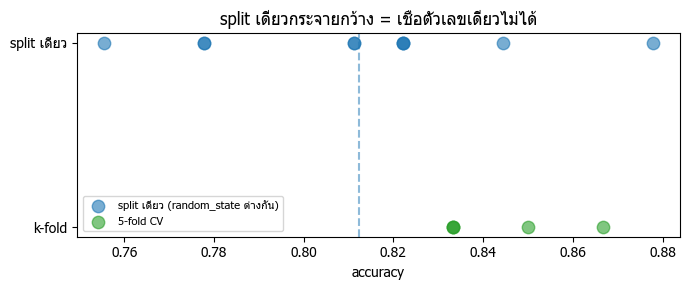


💡 เสมอ: รายงานเป็น 'ค่าเฉลี่ย ± ส่วนเบี่ยงเบน' จาก CV ไม่ใช่ตัวเลขเดียวจาก split เดียว
   และอย่าลืม — preprocessing ต้องอยู่ใน Pipeline เพื่อให้แต่ละ fold ไม่ leak (Part 1)


In [4]:
# ── ดูว่า "split เดียว" ผันผวนแค่ไหน เทียบกับ k-fold ──
X, y = make_classification(n_samples=300, n_features=20, n_informative=8, random_state=3)

# split เดียว แต่เปลี่ยน random_state 10 แบบ → ได้คะแนนต่างกันมาก
single = []
for rs in range(10):
    a, b, c, d = train_test_split(X, y, test_size=0.3, random_state=rs)
    single.append(accuracy_score(d, RandomForestClassifier(n_estimators=80, random_state=0).fit(a, c).predict(b)))

# 5-fold CV
cv_scores = cross_val_score(RandomForestClassifier(n_estimators=80, random_state=0), X, y, cv=5)

print(f"split เดียว (10 แบบ): {min(single):.0%} – {max(single):.0%}  → ต่างกันถึง {max(single)-min(single):.0%}!")
print(f"5-fold CV          : {cv_scores.mean():.0%} ± {cv_scores.std():.0%}  (นิ่งกว่า + บอกความไม่แน่นอนด้วย)")

fig, ax = plt.subplots(figsize=(7, 3))
ax.scatter(single, [1]*len(single), s=80, alpha=0.6, label="split เดียว (random_state ต่างกัน)")
ax.scatter(cv_scores, [0]*len(cv_scores), s=80, alpha=0.6, color="tab:green", label="5-fold CV")
ax.axvline(np.mean(single), ls="--", color="tab:blue", alpha=0.5)
ax.set_yticks([0, 1], ["k-fold", "split เดียว"]); ax.set_xlabel("accuracy")
ax.set_title("split เดียวกระจายกว้าง = เชื่อตัวเลขเดียวไม่ได้"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print("\n💡 เสมอ: รายงานเป็น 'ค่าเฉลี่ย ± ส่วนเบี่ยงเบน' จาก CV ไม่ใช่ตัวเลขเดียวจาก split เดียว")
print("   และอย่าลืม — preprocessing ต้องอยู่ใน Pipeline เพื่อให้แต่ละ fold ไม่ leak (Part 1)")

---
## Part 3 — เลือก Metric ให้ตรงงาน

**accuracy หลอกตาได้ง่ายมาก** โดยเฉพาะข้อมูลไม่สมดุล — ทบทวนจากเล่ม 3 แล้วลงลึกกว่าเดิม

กฎเหล็ก 2 ข้อ:
1. **เทียบกับ baseline เสมอ** — โมเดล "ขี้เกียจ" (ทายคลาสที่เยอะสุดทุกครั้ง) ได้เท่าไร?
2. **เลือก metric ตามความเสียหายจริง** — accuracy, precision, recall, F1, ROC-AUC วัดคนละอย่าง

In [5]:
# ── accuracy เท่ากันเป๊ะ แต่โมเดลคนละเรื่อง ──
Xb, yb = make_classification(n_samples=2000, weights=[0.95, 0.05], n_features=20,
                             n_informative=6, random_state=2)
Xtr, Xte, ytr, yte = train_test_split(Xb, yb, test_size=0.3, random_state=0, stratify=yb)

dummy = DummyClassifier(strategy="most_frequent").fit(Xtr, ytr)          # baseline: ทาย 0 ตลอด
rf = RandomForestClassifier(n_estimators=200, random_state=0, class_weight="balanced").fit(Xtr, ytr)

print(f"{'':22}{'accuracy':>10}{'recall':>9}{'AUC':>7}")
for name, m in [("baseline (ทายคลาสเดียว)", dummy), ("Random Forest", rf)]:
    p = m.predict(Xte); proba = m.predict_proba(Xte)[:, 1]
    print(f"{name:22}{accuracy_score(yte,p):>9.0%}{recall_score(yte,p):>9.0%}{roc_auc_score(yte,proba):>7.2f}")

print(f"\n→ accuracy เท่ากัน 95% ทั้งคู่! ดูจาก accuracy อย่างเดียวจะคิดว่าโมเดลไม่ได้ดีกว่า baseline เลย")
print(f"  แต่ AUC เผยความจริง: baseline 0.50 (เดามั่ว) vs RF 0.97 (แยกได้ดีมาก)")
print(f"\nเลือก metric ตามงาน:  recall สำคัญเมื่อ 'พลาดของจริงแล้วแพง' (ตรวจโรค/ทุจริต)")
print(f"                      precision สำคัญเมื่อ 'เตือนผิดแล้วแพง' (กรอง spam)")

                        accuracy   recall    AUC
baseline (ทายคลาสเดียว)      95%       0%   0.50
Random Forest               95%      10%   0.97

→ accuracy เท่ากัน 95% ทั้งคู่! ดูจาก accuracy อย่างเดียวจะคิดว่าโมเดลไม่ได้ดีกว่า baseline เลย
  แต่ AUC เผยความจริง: baseline 0.50 (เดามั่ว) vs RF 0.97 (แยกได้ดีมาก)

เลือก metric ตามงาน:  recall สำคัญเมื่อ 'พลาดของจริงแล้วแพง' (ตรวจโรค/ทุจริต)
                      precision สำคัญเมื่อ 'เตือนผิดแล้วแพง' (กรอง spam)


---
## Part 4 — Calibration & Threshold: "ความมั่นใจ" ที่เชื่อได้?

เวลาโมเดลบอก "มั่นใจ 90%" — มันจริงไหม? ใน 100 ครั้งที่บอก 90% เกิดขึ้นจริง 90 ครั้งหรือเปล่า?
ถ้าใช่ = **calibrated** (เชื่อความน่าจะเป็นได้) ถ้าไม่ = ตัวเลขความมั่นใจหลอก — สำคัญมากเวลาเอาไปตัดสินใจต่อ

**Reliability diagram** เทียบ "ความน่าจะเป็นที่โมเดลบอก" กับ "ความถี่ที่เกิดจริง" — ควรอยู่บนเส้นทแยง

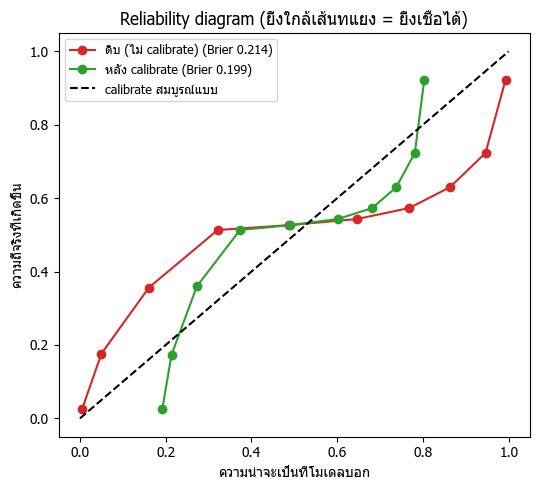

เส้นแดงเบี่ยงจากเส้นทแยง = ความน่าจะเป็นเชื่อไม่ได้ | calibrate ดึงเข้าใกล้ + Brier score ลดลง


In [6]:
# ── โมเดลที่ "มั่นใจเกินจริง" + การ calibrate ──
# ใช้ชื่อตัวแปรแยก (Xc_*) เพื่อไม่ให้ทับ Xte/yte ของ Part 3 ที่ cell threshold ถัดไปยังต้องใช้
Xc, yc = make_classification(n_samples=6000, n_features=20, n_informative=6, n_redundant=10,
                             n_clusters_per_class=2, random_state=7)
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(Xc, yc, test_size=0.5, random_state=0)

nb = GaussianNB().fit(Xc_tr, yc_tr)                             # NB มักมั่นใจเกินจริง
nb_cal = CalibratedClassifierCV(GaussianNB(), method="sigmoid", cv=5).fit(Xc_tr, yc_tr)

fig, ax = plt.subplots(figsize=(5.5, 5))
for m, name, col in [(nb, "ดิบ (ไม่ calibrate)", "tab:red"), (nb_cal, "หลัง calibrate", "tab:green")]:
    proba = m.predict_proba(Xc_te)[:, 1]
    frac, mean_pred = calibration_curve(yc_te, proba, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac, "o-", color=col, label=f"{name} (Brier {brier_score_loss(yc_te,proba):.3f})")
ax.plot([0, 1], [0, 1], "k--", label="calibrate สมบูรณ์แบบ")
ax.set_xlabel("ความน่าจะเป็นที่โมเดลบอก"); ax.set_ylabel("ความถี่จริงที่เกิดขึ้น")
ax.set_title("Reliability diagram (ยิ่งใกล้เส้นทแยง = ยิ่งเชื่อได้)"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()
print("เส้นแดงเบี่ยงจากเส้นทแยง = ความน่าจะเป็นเชื่อไม่ได้ | calibrate ดึงเข้าใกล้ + Brier score ลดลง")

ผลของ threshold ต่อ recall/precision (ข้อมูลไม่สมดุลจาก Part 3):
  threshold 0.5: recall 10%  precision 100%
  threshold 0.3: recall 39%  precision 86%
  threshold 0.15: recall 65%  precision 56%


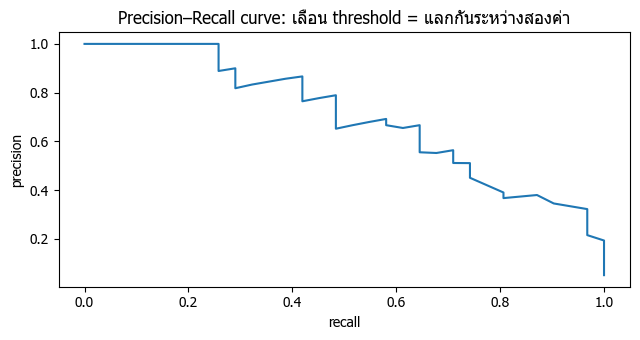


💡 default 0.5 ให้ recall ต่ำในข้อมูลไม่สมดุล — ลด threshold เพิ่ม recall (แต่ precision ลด)
   ⚠️ เลือก threshold จาก 'validation set' แล้วรายงานบน test — ห้ามจูน threshold บน test


In [7]:
# ── Threshold: ค่า default 0.5 ไม่ใช่คำตอบเสมอ ──
# ใช้ RF จาก Part 3 (ข้อมูลไม่สมดุล) — ดู recall ที่ threshold ต่าง ๆ
proba = rf.predict_proba(Xte)[:, 1]
print("ผลของ threshold ต่อ recall/precision (ข้อมูลไม่สมดุลจาก Part 3):")
for thr in [0.5, 0.3, 0.15]:
    pred = (proba >= thr).astype(int)
    print(f"  threshold {thr}: recall {recall_score(yte,pred):.0%}  precision {precision_score(yte,pred,zero_division=0):.0%}")

prec, rec, thresholds = precision_recall_curve(yte, proba)
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.plot(rec, prec)
ax.set_xlabel("recall"); ax.set_ylabel("precision")
ax.set_title("Precision–Recall curve: เลื่อน threshold = แลกกันระหว่างสองค่า")
plt.tight_layout(); plt.show()
print("\n💡 default 0.5 ให้ recall ต่ำในข้อมูลไม่สมดุล — ลด threshold เพิ่ม recall (แต่ precision ลด)")
print("   ⚠️ เลือก threshold จาก 'validation set' แล้วรายงานบน test — ห้ามจูน threshold บน test")

---
## Part 5 — Overfitting to the Test Set: หลอกตัวเองแบบเนียน ๆ

ถ้าลองโมเดล/hyperparameter หลายสิบแบบแล้ว **เลือกตัวที่ดีที่สุดบน test set** — ตัวเลขที่ได้จะ "ดีเกินจริง"
เพราะคุณกำลัง overfit ไปกับ test set โดยอ้อม (เลือกตัวที่บังเอิญเข้ากับ test ชุดนั้น)

พิสูจน์อีกครั้งด้วย **ข้อมูล noise ล้วน** — ลองหลายโมเดลแล้วเชียร์ตัวที่ดีที่สุด:

In [8]:
# ── เลือกตัวที่ดีที่สุดจาก 150 โมเดล "บน noise" → ดูเหมือนเก่ง แต่ไม่จริง ──
rng2 = np.random.default_rng(5)
X = rng2.normal(size=(450, 60)); y = rng2.integers(0, 2, 450)        # noise ล้วน
Xtr, Xtmp, ytr, ytmp = train_test_split(X, y, test_size=0.5, random_state=0)
Xval, Xtest, yval, ytest = train_test_split(Xtmp, ytmp, test_size=0.5, random_state=0)  # val + test แยกกัน

best_val, best_model, best_cols = -1, None, None
for _ in range(150):                                                  # ลอง 150 โมเดล (สุ่ม feature)
    cols = rng2.choice(60, 6, replace=False)
    m = LogisticRegression(max_iter=500).fit(Xtr[:, cols], ytr)
    v = accuracy_score(yval, m.predict(Xval[:, cols]))
    if v > best_val: best_val, best_model, best_cols = v, m, cols

test_acc = accuracy_score(ytest, best_model.predict(Xtest[:, best_cols]))
print(f"ลอง 150 โมเดลบน noise ล้วน (ความจริง = 50%):")
print(f"  คะแนนของ 'ตัวที่ดีที่สุด' บน validation : {best_val:.0%}   ← เย้! เจอโมเดลเก่ง?")
print(f"  คะแนนตัวเดียวกันบน test ใหม่ที่ไม่เคยแตะ : {test_acc:.0%}   ← ภาพลวงตาหายวับ กลับเป็นเดามั่ว")
print(f"\n→ ยิ่งลองเยอะ ยิ่งมีโมเดลที่ 'บังเอิญ' เข้ากับ validation — ไม่ได้แปลว่ามันเก่งจริง")

ลอง 150 โมเดลบน noise ล้วน (ความจริง = 50%):
  คะแนนของ 'ตัวที่ดีที่สุด' บน validation : 59%   ← เย้! เจอโมเดลเก่ง?
  คะแนนตัวเดียวกันบน test ใหม่ที่ไม่เคยแตะ : 49%   ← ภาพลวงตาหายวับ กลับเป็นเดามั่ว

→ ยิ่งลองเยอะ ยิ่งมีโมเดลที่ 'บังเอิญ' เข้ากับ validation — ไม่ได้แปลว่ามันเก่งจริง


**วิธีไม่ตกหลุมนี้:**
- แบ่งข้อมูล 3 ส่วน: **train** (สอน) / **validation** (จูน & เลือกโมเดล) / **test** (แตะครั้งเดียวตอนจบ)
- หรือใช้ **nested cross-validation** (CV ซ้อน CV) เมื่อข้อมูลน้อย
- **test set ศักดิ์สิทธิ์** — เปิดดูครั้งเดียวตอนจบสุด ห้ามใช้เลือกอะไรทั้งนั้น
- ยิ่งลองหลายอย่าง ยิ่งต้องระวัง "multiple comparisons" — บางตัวดูดีเพราะโชค ไม่ใช่ฝีมือ

---
## Part 6 — Checklist ก่อนเชื่อผลลัพธ์ ✅

พิมพ์ติดไว้ข้างจอ — เช็คก่อนจะเชื่อตัวเลขใด ๆ ที่โมเดลให้มา

### 🔍 ก่อนเทรน
- [ ] แบ่ง train / validation / test **ตั้งแต่แรก** ก่อนแตะข้อมูล
- [ ] preprocessing (scale, เลือก feature, fill missing) อยู่ใน **`Pipeline`** ที่ fit จาก train เท่านั้น
- [ ] เช็ก **target leakage** — มี feature ไหนที่ "รู้คำตอบ" หรือมาจากอนาคตไหม?
- [ ] ข้อมูลเป็น time series? ใช้ **time-based split** ไม่ใช่สุ่ม

### 📊 ตอนประเมิน
- [ ] เทียบกับ **baseline** (DummyClassifier) เสมอ
- [ ] ใช้ **k-fold CV** รายงานเป็น **ค่าเฉลี่ย ± SD** ไม่ใช่ split เดียว
- [ ] เลือก **metric ตามความเสียหายจริง** ของงาน (ไม่ใช่ accuracy อัตโนมัติ)
- [ ] ข้อมูลไม่สมดุล? ดู **precision/recall/AUC** ไม่ใช่ accuracy
- [ ] ต้องใช้ความน่าจะเป็น? เช็ก **calibration**

### 🎯 ก่อนสรุป
- [ ] **test set แตะครั้งเดียว** ตอนจบ — ไม่ใช้เลือกโมเดล/threshold/feature
- [ ] ลองหลายโมเดล? ระวัง **overfitting to test set**
- [ ] ผลดี "เกินจริง" ไหม? → สงสัย leakage ไว้ก่อน (ผลที่ดีเกินไปมักมีอะไรผิด)
- [ ] รันซ้ำด้วย seed อื่นแล้วผลยังนิ่งไหม?

---

### 🎓 สรุปทั้ง 7 เล่ม

| เล่ม | แก่น |
|---|---|
| 1 — ML Fundamentals | neuron → CNN → attention → mini GPT |
| 2 — LLM Deep Dive | tokenizer → pretrain → fine-tune |
| 3 — ML × Network Security | classical ML + unsupervised + adversarial |
| 4 — Reinforcement Learning | Q-learning → DQN → REINFORCE → RLHF |
| 5 — Generative Vision | VAE → GAN → Diffusion |
| 6 — Graph Neural Networks | message passing → GCN → botnet detection |
| 7 — ML Pitfalls | **ทำให้ถูก: leakage, CV, metric, calibration, test discipline** |

> 6 เล่มแรกสอน "สร้างโมเดล" — เล่มนี้สอน "เชื่อโมเดลเมื่อไรได้"
> ทักษะที่แยกมือสมัครเล่นกับมืออาชีพ ไม่ใช่การรู้โมเดลเยอะ แต่คือ**การไม่หลอกตัวเอง**

### แหล่งเรียนรู้ต่อ
- 📄 *Data Leakage in Machine Learning* (Kaufman et al.) — รวมกรณี leakage ในงานจริง
- 📖 scikit-learn — *Common pitfalls and recommended practices* (หน้า doc ที่ควรอ่าน)
- 📄 Cawley & Talbot (2010) — *On Over-fitting in Model Selection* (ต้นตอ leakage จากการเลือกโมเดล)
- 📖 *Weapons of Math Destruction* (Cathy O'Neil) — เมื่อ ML ที่ประเมินผิดสร้างความเสียหายจริงในสังคม